In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("IPL.csv")
df.head()

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,133,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,179,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,208,5,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,161,5,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,149,7,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22


In [3]:
df[['wickets', 'runs']] = df['best_bowling_figure'].str.split('--', expand=True)
df['wickets'] = pd.to_numeric(df['wickets'])
df['runs'] = pd.to_numeric(df['runs'])

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   match_id             74 non-null     int64
 1   date                 74 non-null     str  
 2   venue                74 non-null     str  
 3   team1                74 non-null     str  
 4   team2                74 non-null     str  
 5   stage                74 non-null     str  
 6   toss_winner          74 non-null     str  
 7   toss_decision        74 non-null     str  
 8   first_ings_score     74 non-null     int64
 9   first_ings_wkts      74 non-null     int64
 10  second_ings_score    74 non-null     int64
 11  second_ings_wkts     74 non-null     int64
 12  match_winner         74 non-null     str  
 13  won_by               74 non-null     str  
 14  margin               74 non-null     int64
 15  player_of_the_match  74 non-null     str  
 16  top_scorer           74 non-null     st

In [5]:
df.shape

(74, 22)

In [6]:
df.isnull().sum()

match_id               0
date                   0
venue                  0
team1                  0
team2                  0
stage                  0
toss_winner            0
toss_decision          0
first_ings_score       0
first_ings_wkts        0
second_ings_score      0
second_ings_wkts       0
match_winner           0
won_by                 0
margin                 0
player_of_the_match    0
top_scorer             0
highscore              0
best_bowling           0
best_bowling_figure    0
wickets                0
runs                   0
dtype: int64

## 1. Most Successful Teams


In [7]:
match_wins = df["match_winner"].value_counts()
print(f"Indexs = {match_wins.index}")
print(f"Values = {match_wins.values}")
print(match_wins)

Indexs = Index(['Gujarat', 'Rajasthan', 'Banglore', 'Lucknow', 'Delhi', 'Punjab',
       'Kolkata', 'Hyderabad', 'Chennai', 'Mumbai'],
      dtype='str', name='match_winner')
Values = [12 10  9  9  7  7  6  6  4  4]
match_winner
Gujarat      12
Rajasthan    10
Banglore      9
Lucknow       9
Delhi         7
Punjab        7
Kolkata       6
Hyderabad     6
Chennai       4
Mumbai        4
Name: count, dtype: int64


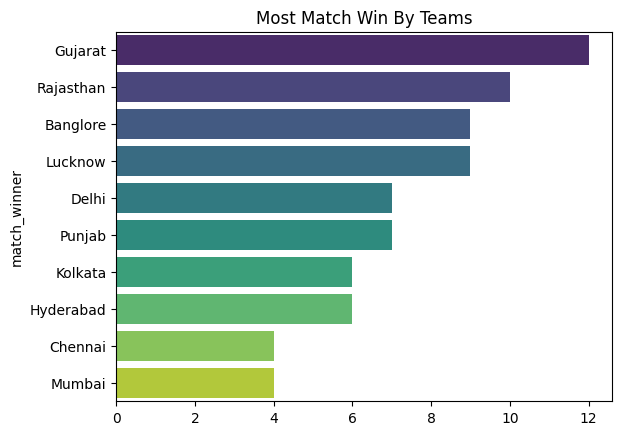

In [8]:
sns.barplot(y = match_wins.index, x = match_wins.values,hue = match_wins.index,legend=False,palette = "viridis")
plt.title("Most Match Win By Teams")
plt.savefig("images/most_wins.png", bbox_inches='tight')

**Gujarat won the highest number of matches (12), making them the most dominant team in this dataset. Mumbai and Chennai performed poorly compared to other teams.**

## 2.Toss Decision Trends

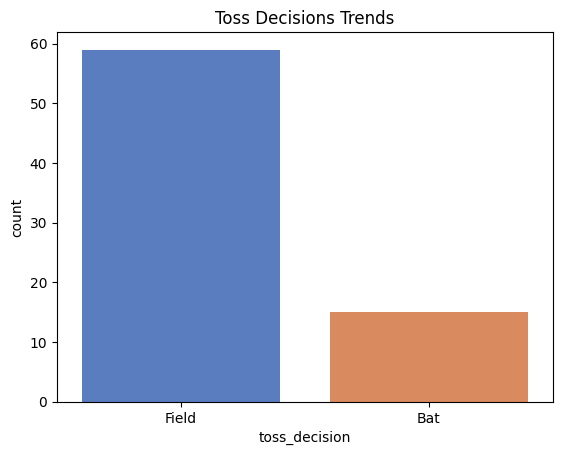

In [9]:
sns.countplot(x = df["toss_decision"],hue = df["toss_decision"],legend=False,palette = "muted")
plt.title("Toss Decisions Trends")
plt.savefig("images/toss_decision.png", bbox_inches='tight')

**Most teams prefer to field first after winning the toss, indicating a strategic advantage in chasing targets.**

## 3. Toss Impact on Match Outcome

In [10]:
count = df[df["toss_winner"] == df["match_winner"]]["match_id"].count()

In [11]:
percentage = (count * 100)/df.shape[0]
percentage

np.float64(48.648648648648646)

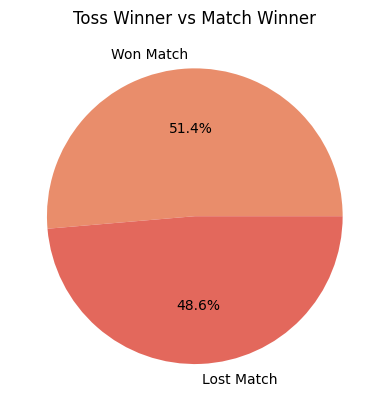

In [12]:
toss_result = df['toss_winner'] == df['match_winner']

labels = ['Won Match', 'Lost Match']
values = toss_result.value_counts()
my_colors = sns.color_palette('flare')
plt.figure()
plt.pie(values, labels=labels, autopct='%1.1f%%',colors=my_colors)
plt.title("Toss Winner vs Match Winner")
plt.savefig("images/toss_impact.png", bbox_inches='tight')
plt.show()


**Approximately 48.6% of toss winners also won the match, showing that toss advantage is not a strong predictor of match outcome.**

## 4.Bat vs Field

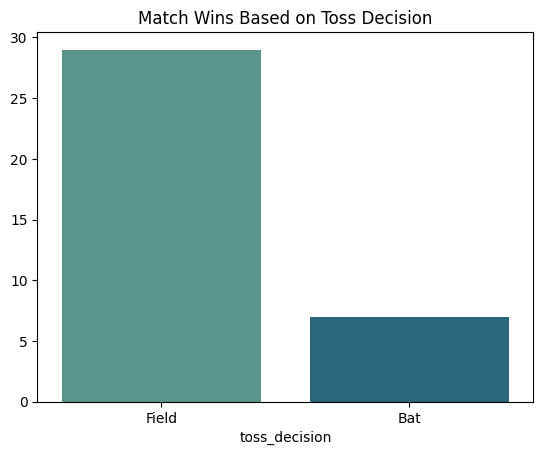

In [13]:
decision_win = df[df['toss_winner'] == df['match_winner']]['toss_decision']

decision_win_count = decision_win.value_counts()

sns.barplot(
    x=decision_win_count.index,y=decision_win_count.values,hue=decision_win_count.index,legend = False,palette = 'crest'
)

plt.title("Match Wins Based on Toss Decision")
plt.savefig("images/bat_vs_field.png", bbox_inches='tight')
plt.show()


**Teams that chose to field after winning the toss tend to win more matches compared to those who chose to bat, indicating a possible advantage in chasing.**

## 5. Match Winning Type (Runs vs Wickets)

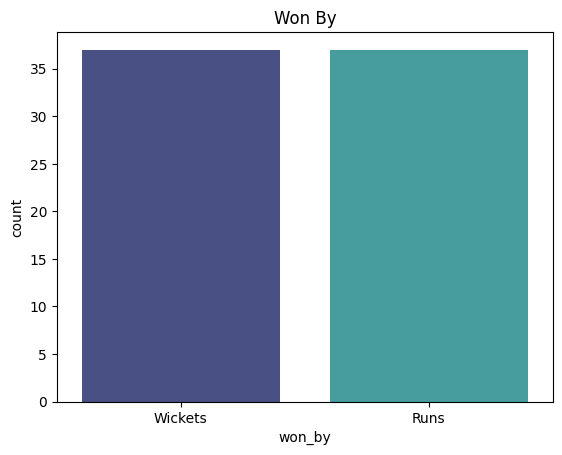

In [14]:
sns.countplot(x = df["won_by"],hue = df["won_by"],legend = False,palette = "mako")
plt.title("Won By")
plt.savefig("images/win_type.png", bbox_inches='tight')

**Both wickets and runs have equally been won in this dataset.**

## 6. Player Performance (Man of the Match)

In [15]:
count = df["player_of_the_match"].value_counts().head(10)
count


player_of_the_match
Kuldeep Yadav        4
Jos Buttler          3
Umesh Yadav          2
Wanindu Hasaranga    2
Avesh Khan           2
Dinesh Karthik       2
Quinton de Kock      2
Shubman Gill         2
Yuzvendra Chahal     2
Hardik Pandya        2
Name: count, dtype: int64

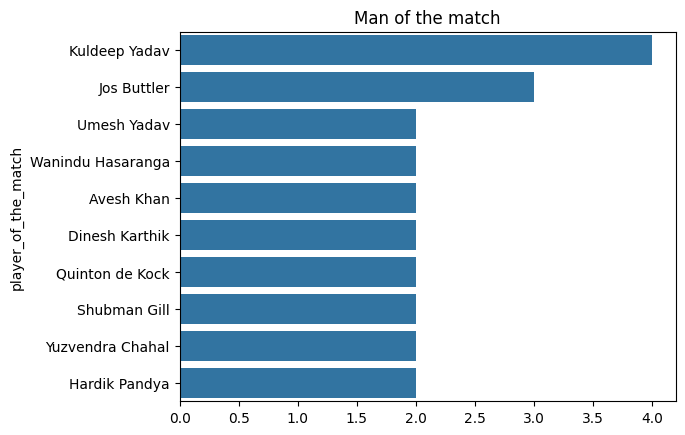

In [16]:
sns.barplot(x = count.values, y = count.index)
plt.title("Man of the match")
plt.savefig("images/motm.png", bbox_inches='tight')

**Kuldeep Yadav was the highest number of Man of the Match title, indicating consistent high-impact performances.**

## 7. Top 3 scorers

In [17]:
high = df.groupby("top_scorer")["highscore"].sum().sort_values(ascending = False).head(3)
high

top_scorer
Jos Buttler        651
Quinton de Kock    377
KL Rahul           351
Name: highscore, dtype: int64

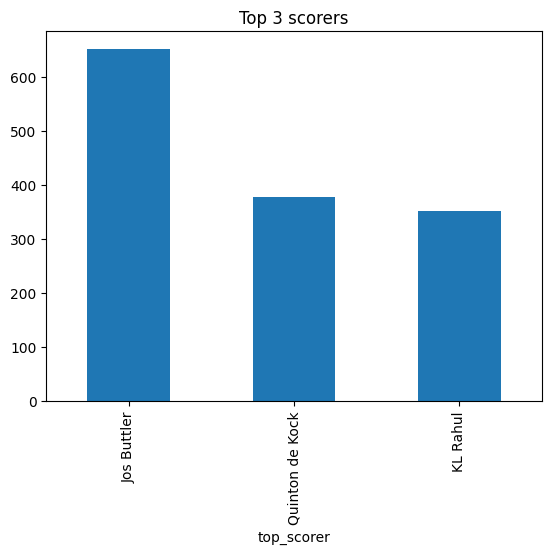

In [18]:
high.plot(kind = 'bar')
plt.title("Top 3 scorers")
plt.savefig("images/", bbox_inches='tight')
plt.savefig("images/top_scorers.png", bbox_inches='tight')

**Jos Buttler has the highest total runs among top scorers, showing consistent batting performance.**

## 8. Best Bowling Performances

In [19]:
top_bowlers = (
    df.sort_values(by=["wickets", "runs"], ascending=[False, True])
    [['best_bowling', 'wickets', 'runs']]
    .head(10)
)

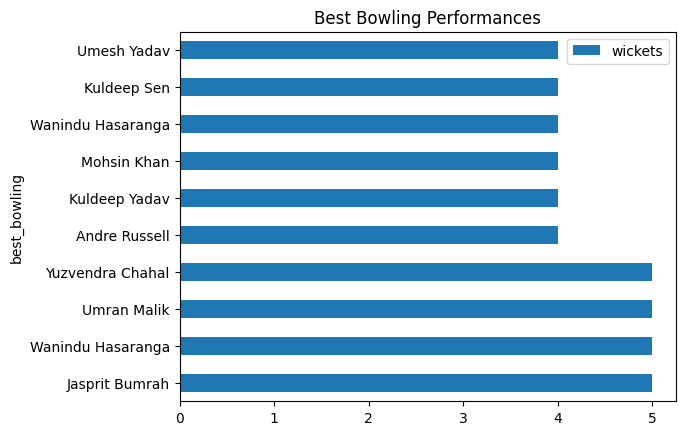

In [20]:
top_bowlers.plot(
    kind='barh',
    x='best_bowling',
    y='wickets'
)
plt.title("Best Bowling Performances")
plt.savefig("images/bowling.png", bbox_inches='tight')
plt.show()


**Top bowling performances are defined by high wickets and low runs conceded. Players like Yuzvendra Chahal and Jasprit Bumrah stand out.**

## 9. Venue Analysis

**Most Matches Played by Venue**

In [21]:
venue_count = df['venue'].value_counts()

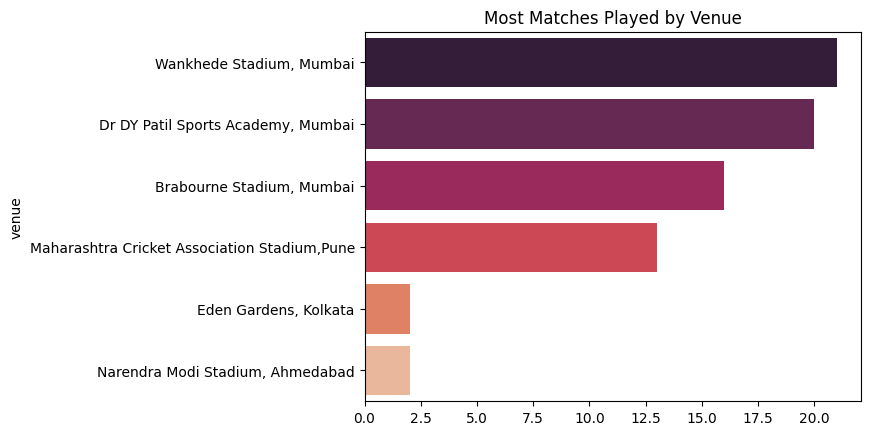

In [26]:
sns.barplot(x = venue_count.values, y = venue_count.index,hue = venue_count.index ,legend = False,palette='rocket')
plt.title("Most Matches Played by Venue")
plt.savefig("images/venue.png", bbox_inches='tight')

**Most matches were played at Wankhede Stadium, making it the primary venue in this dataset.**

## 10. Custom Questions

**Q1 : Who won the highest margin by runs?**

In [23]:

df[df['won_by'] == 'Runs'].sort_values(by = 'margin',ascending=False).head(1)[['match_winner','margin']]

,match_winner,margin
54,Chennai,91


**Chennai recorded the highest win margin by runs (91), indicating a highly dominant performance.**

**Q2: Which player had the highest individual score?**

In [24]:
df[df['highscore'] == df['highscore'].max()][['top_scorer','highscore']]

,top_scorer,highscore
65,Quinton de Kock,140


**Quinton de Kock scored the highest individual score (140), making it the standout batting performance.**

**Q3: Which bowler had the best bowling figures?**

In [25]:
df[df['wickets'] == df['wickets'].max()][['best_bowling','best_bowling_figure']]

,best_bowling,best_bowling_figure
29,Yuzvendra Chahal,5--40
39,Umran Malik,5--25
53,Wanindu Hasaranga,5--18
55,Jasprit Bumrah,5--10


**Jasprit Bumrah achieved the best bowling figure (5–10), showing exceptional efficiency.**

##  Key Insights Summary

- Gujarat was the most dominant team with the highest number of wins  
- Toss does not significantly impact match outcomes (~48.6%)  
- Teams choosing to field first tend to win more matches  
- Most matches are won by wickets, suggesting a chasing advantage  
- Kuldeep Yadav stands out with the most Man of the Match awards  
- Jos Buttler leads in overall scoring performance  
- Jasprit Bumrah delivered the most efficient bowling performance (5–10)